## Course Project
## Sara Mohseni 401102434

In [ ]:
! pip install gymnasium


In [ ]:
! pip install gymnasium[toy_text]


In [ ]:
! pip install "gymnasium[toy-text]"


## Main algorithm (the latest version after testing with different parameters, expalined in report)

In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import pickle
dim = '8x8'
num_episodes = 25000
def run(episodes, is_training=True, render=False, slippery = True, rendermode = 'human'):

    env = gym.make('FrozenLake-v1', map_name=dim, is_slippery=slippery, render_mode=rendermode if render else None)

    if(is_training):
        q = np.zeros((env.observation_space.n, env.action_space.n)) # init a dim x 4 array
    else:
        f = open('frozen_lake{}.pkl'.format(dim), 'rb')
        q = pickle.load(f)
        f.close()

    learning_rate_a = 0.1 # alpha or learning rate
    discount_factor_g = 0.99 # gamma or discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state.
    epsilon = 1        # 1 = 100% random actions
    epsilon_start = 1.0
    epsilon_min = 0.01
    decay_rate = 0.0005


    rewards_per_episode = np.zeros(episodes)

    for i in range(episodes):
        state = env.reset()[0]  # states: 0 to 63, 0=top left corner,63=bottom right corner
        terminated = False      # True when fall in hole or reached goal
        truncated = False       # True when actions > 200

        while(not terminated and not truncated):
            if is_training and random.uniform(0, 1) < epsilon:
                action = env.action_space.sample() # actions: 0=left,1=down,2=right,3=up
            else:
                action = np.argmax(q[state,:])
                #print(action)

            new_state,reward,terminated,truncated,_ = env.step(action)
            #print(env.step(action))
            if terminated and reward == 0:
                rewardh = -5  # Stronger penalty for hole
            elif terminated and reward == 1:
                rewardh = 10  # Higher reward for goal
            else:
                rewardh = -0.1  # Small penalty for each step

            if is_training:
                q[state,action] = q[state,action] + learning_rate_a * (
                    rewardh + discount_factor_g * np.max(q[new_state,:]) - q[state,action]
                )

            state = new_state

        epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-decay_rate * i)


        if(epsilon==0):
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1
        

    env.close()

    if is_training:
        f = open("frozen_lake{}.pkl".format(dim),"wb")
        pickle.dump(q, f)
        f.close()

    return rewards_per_episode

def myplot(episodes,title,input ,phase, env):
    sum_rewards = np.zeros(episodes)
    plt.figure()
    for t in range(episodes):
            sum_rewards[t] = np.sum(input[max(0, t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.title('{}_{}_{}'.format(title,phase,env))
    plt.savefig('frozen_lake8x8_accuracy_{}_{}.png'.format(phase,env))
    print(phase+'_'+env)
    print(np.sum(input)/episodes*100)


    
    


Train_slippery
45.76
Test_slippery
62.544


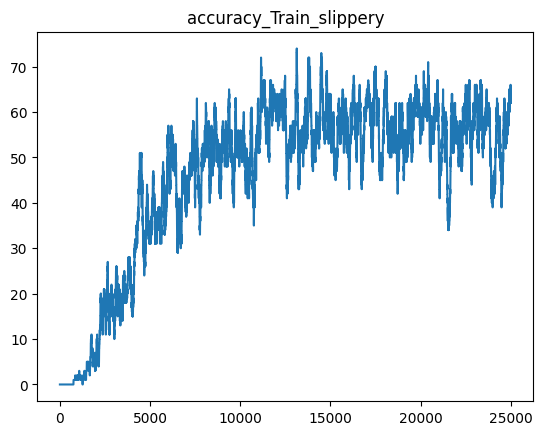

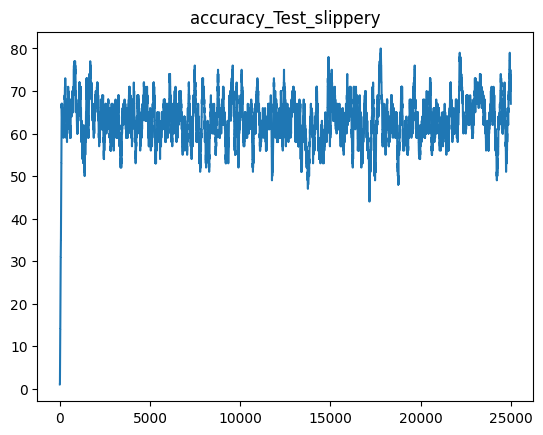

In [5]:
if __name__ == '__main__':

    #train
    myplot(num_episodes,'accuracy',run(num_episodes),'Train', 'slippery')
    #test
    myplot(num_episodes,'accuracy',run(num_episodes,False),'Test', 'slippery')

Train_non slippery
85.736
Test_non slippery
100.0


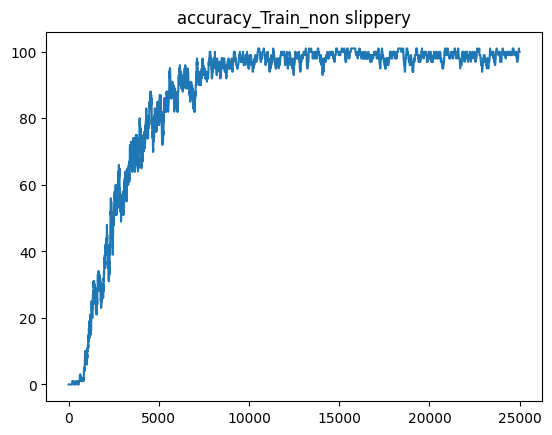

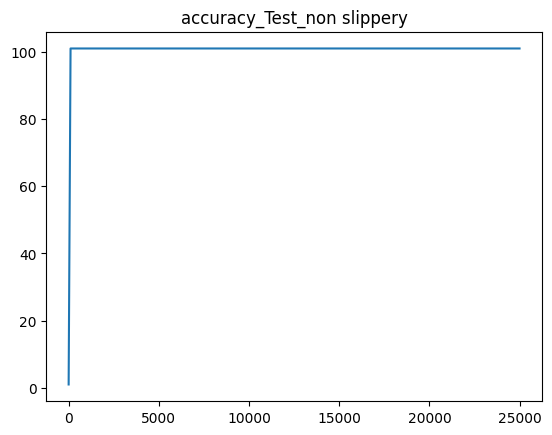

In [6]:
#train
myplot(num_episodes,'accuracy',run(int(num_episodes),slippery=False),'Train', 'non slippery')
    
#test
myplot(num_episodes,'accuracy',run(int(num_episodes),False,slippery=False),'Test', 'non slippery')

## Ansi Mode

In [5]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import pickle

dim = '8x8'
num_episodes = 25000
ansi_frames = []  # Store ANSI frames
def runansi(episodes, is_training=True, render=False, slippery=False, rendermode='ansi'):

    env = gym.make('FrozenLake-v1', map_name=dim, is_slippery=slippery, render_mode=rendermode if render else None)

    if is_training:
        q = np.zeros((env.observation_space.n, env.action_space.n))
    else:
        with open('frozen_lake{}.pkl'.format(dim), 'rb') as f:
            q = pickle.load(f)

    learning_rate_a = 0.1
    discount_factor_g = 0.99
    epsilon = 1.0
    epsilon_start = 1.0
    epsilon_min = 0.01
    decay_rate = 0.0005

    rewards_per_episode = np.zeros(episodes)


    for i in range(episodes):
        state = env.reset()[0]
        terminated = False
        truncated = False

        while not terminated and not truncated:
            if is_training and random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q[state, :])

            new_state, reward, terminated, truncated, _ = env.step(action)

            if terminated and reward == 0:
                rewardh = -5
            elif terminated and reward == 1:
                rewardh = 10
            else:
                rewardh = -0.1

            if is_training:
                q[state, action] += learning_rate_a * (
                    rewardh + discount_factor_g * np.max(q[new_state, :]) - q[state, action]
                )

            state = new_state

            if render:
                frame = env.render()
                if isinstance(frame, str):
                    ansi_frames.append(frame)

        epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-decay_rate * i)

        if epsilon == 0:
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()

    if is_training:
        with open("frozen_lake{}.pkl".format(dim), "wb") as f:
            pickle.dump(q, f)

    if render:
        with open("frozen_lake_ansi_output.txt", "w") as f:
            for idx, frame in enumerate(ansi_frames):
                f.write(f"Step {idx + 1}:\n")
                f.write(frame)
                f.write("\n" + "-" * 40 + "\n")

    return rewards_per_episode


In [2]:
from PIL import Image, ImageDraw, ImageFont
import os

def ansi_to_images(ansi_frames, output_folder="ansi_frames"):
    os.makedirs(output_folder, exist_ok=True)

    # Use a monospaced font like Courier
    font = ImageFont.load_default()
    font_size = 14
    padding = 10

    for i, frame in enumerate(ansi_frames):
        lines = frame.strip().split('\n')
        width = max(len(line) for line in lines)
        height = len(lines)

        image = Image.new('RGB', (8 * width + 2 * padding, font_size * height + 2 * padding), color='white')
        draw = ImageDraw.Draw(image)

        for j, line in enumerate(lines):
            draw.text((padding, j * font_size + padding), line, font=font, fill='black')

        image.save(f"{output_folder}/frame_{i:04d}.png")


In [3]:
def images_to_gif(input_folder="ansi_frames", gif_name="frozenlake.gif", duration=300):
    images = []
    files = sorted([f for f in os.listdir(input_folder) if f.endswith(".png")])
    for filename in files:
        img = Image.open(os.path.join(input_folder, filename))
        images.append(img)

    if images:
        images[0].save(
            gif_name,
            save_all=True,
            append_images=images[1:],
            duration=duration,
            loop=0
        )


In [6]:
runansi(episodes=1000, is_training=True)
ansi_frames = []  # Store ANSI frames
runansi(episodes=5, is_training=False, render=True)

# Save images and gif
ansi_to_images(ansi_frames)         # Convert frames to images
images_to_gif(gif_name="frozenlake.gif")  # Create the gif

